<a href="https://colab.research.google.com/github/kylermurphy/contigo_edr/blob/main/CONTIGO_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONTIGO EDR Example

This notebook goes over a simple example for deriving the energy dissipation rate from the ```contigo``` module.

The first three cells setup the working environment including:
- Installing GMAT the NASA General Mission Analysis Tool
- Retrieving and installing the ```contigo``` module.

**NOTE** that after running the first three cells the session has to be restarted. This is done in the fourth cell. **Because of this you cannot use the ```Run all``` command.

In [8]:
# Download GMAT (adjust the link for the specific version you need)
!wget -q https://sourceforge.net/projects/gmat/files/GMAT/GMAT-R2025a/gmat-ubuntu-x64-R2025a.tar.gz
!tar -xf gmat-ubuntu-x64-R2025a.tar.gz


In [2]:
%%bash
cd /content/GMAT/R2025a/api
python BuildApiStartupFile.py

In [3]:
%%bash
git clone --recursive https://github.com/kylermurphy/contigo_edr.git
cd /content/contigo_edr/
pip install -e .

Obtaining file:///content/contigo_edr
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 40.4 MB/s eta 0:00:00
  Building editable for contigo (pyproject.toml): started
  Building editable for contigo (pyproject.toml): finished with status 'done'
  Created wheel for contigo: filename=contigo-0.1.0-0.editable-py3-none-any.whl size=15515 sha256=8abd6041f1360f5925f78457fd03abae745754b385eb649d6a5c670f7d94b91a
  Stored in

Cloning into 'contigo_edr'...


In [4]:
exit()

In [4]:
import pandas as pd
import numpy as np


from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity


from contigo.ephemeris.spice_ephem import SPICEEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

from contigo.forces.third_body_acc import ThirdBodyAcc
from contigo.forces.third_body_acc import ThirdBody
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_gmat import SRPAcc

ImportError: cannot import name 'SPICEEphem' from 'contigo.ephemeris.spice_ephem' (d:\GitHub\contigo_edr\contigo\ephemeris\spice_ephem.py)

In [10]:
sw_e = pd.read_hdf("/content/contigo_edr/data/ESA_pod.hdf") # holds POD info for EDR calculation
sw_o = pd.read_hdf("/content/contigo_edr/data//ore_d.hdf") # holds EDR calculation from other method for comparison


In [11]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc = Constellation(state_file=r'/content/contigo_edr/data/ESA_pod.hdf',
                    time_col='DateTime', x_col='x', y_col='y', z_col='z',
                    vx_col='vx', vy_col='vy', vz_col='vz',
                    sc_id_col='filename', sc_fn_slc=slice(-11,-8),
                    tscale_input='GPS',
                    sc_mass=4.3e+02, cr=1.8, srp_area=1, cd=3.5, drag_area=1.1)

In [12]:
# setup the ephemeris provider we want
# and the solar system environement
# which defines the tolerance for ephemeris cacheing and the bodies we want
# in our solar system
ephem = SPICEEphem(ephemeris='de440s', frame='ITRF93', observer='EARTH')

env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem,
                             sp_et=hdf_sc.sspice_et, sp_gps=hdf_sc.sspice_gps)

In [13]:
# this is a big lmax but this is what
# we use in the orekit derivation and
# is what we need here to for a comparison
ep = EarthPotential(lmax=100)
tba_env = ThirdBodyEnv( )
srp = SRPAcc(apistartup="api_startup_file.txt", gmat_install="/content/GMAT/R2025a")

In [14]:
edr = EDRDensity(constellation=hdf_sc,
                 solarsys_env= env, force_models=[tba_env,srp],potential_model=ep)

In [15]:
acc_con = edr.compute_edr()

In [16]:
den_con = edr.compute_denom()

True


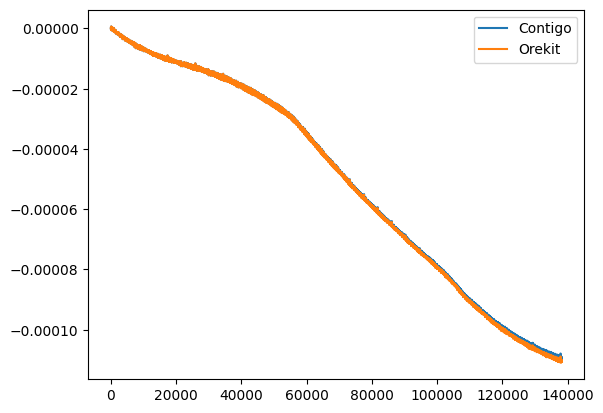

In [28]:
contigo = pd.DataFrame(acc_con['ESA'])
sw_o['edr_km'] = (sw_o['edr']-sw_o['edr'][0])/(1000**2)
ax = contigo['edr'].plot(label='Contigo')
sw_o['edr_km'].plot(ax=ax,label='Orekit')

ax.legend()

ac = np.allclose(sw_o['edr_km'].to_numpy(),contigo['edr'].to_numpy(),atol=1E-7,rtol=0.1)
print(ac)

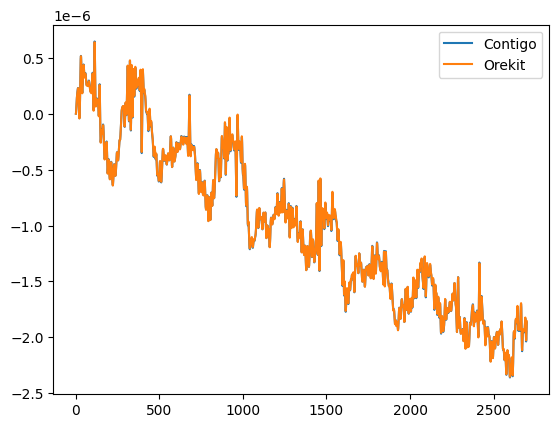

In [29]:
end = int(5*90*60/10)
ax = contigo['edr'][0:end].plot(label='Contigo')
sw_o['edr_km'][0:end].plot(ax=ax, label='Orekit')
ax.legend()